In [125]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [126]:
np.random.seed(42)
X = np.random.rand(100,1) - 0.5
y = 3*X[:, 0]**2 + 0.05 * np.random.randn(100)

In [127]:
df = pd.DataFrame()

In [128]:
df['X'] = X.reshape(100)
df['y'] = y

In [129]:
df

,X,y
0,-0.125460,0.051573
1,0.450714,0.594480
2,0.231994,0.166052
3,0.098658,-0.070178
4,-0.343981,0.343986
...,...,...
95,-0.006204,-0.040675
96,0.022733,-0.002305
97,-0.072459,0.032809
98,-0.474581,0.689516


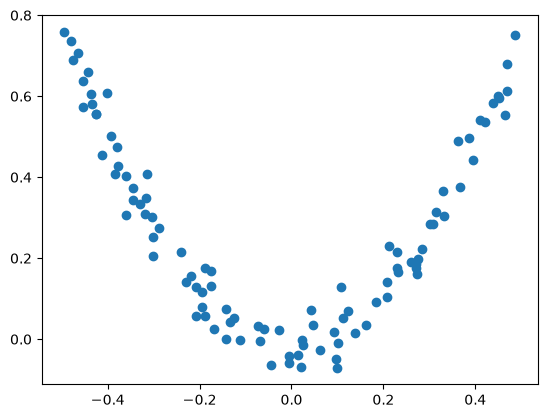

In [130]:
plt.scatter(df['X'],df['y'])

In [131]:
df['pred1'] = df['y'].mean()

In [132]:
df

,X,y,pred1
0,-0.125460,0.051573,0.265458
1,0.450714,0.594480,0.265458
2,0.231994,0.166052,0.265458
3,0.098658,-0.070178,0.265458
4,-0.343981,0.343986,0.265458
...,...,...,...
95,-0.006204,-0.040675,0.265458
96,0.022733,-0.002305,0.265458
97,-0.072459,0.032809,0.265458
98,-0.474581,0.689516,0.265458


In [133]:
df['res1'] = df['y'] - df['pred1']

In [134]:
df

,X,y,pred1,res1
0,-0.125460,0.051573,0.265458,-0.213885
1,0.450714,0.594480,0.265458,0.329021
2,0.231994,0.166052,0.265458,-0.099407
3,0.098658,-0.070178,0.265458,-0.335636
4,-0.343981,0.343986,0.265458,0.078528
...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133
96,0.022733,-0.002305,0.265458,-0.267763
97,-0.072459,0.032809,0.265458,-0.232650
98,-0.474581,0.689516,0.265458,0.424057


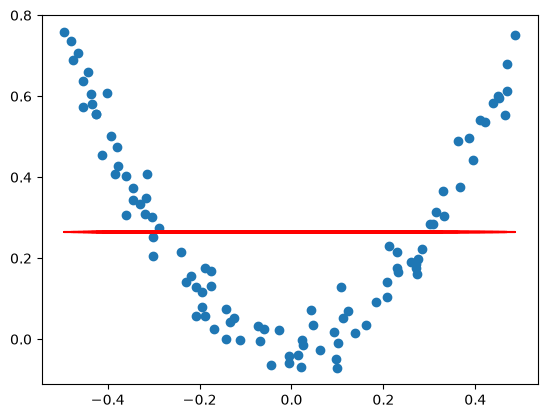

In [135]:
plt.scatter(df['X'],df['y'])
plt.plot(df['X'],df['pred1'],color='red')

In [136]:
from sklearn.tree import DecisionTreeRegressor

In [137]:
t1 = DecisionTreeRegressor(max_depth=8)

In [138]:
t1.fit(df['X'].values.reshape(100,1),df['res1'].values)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

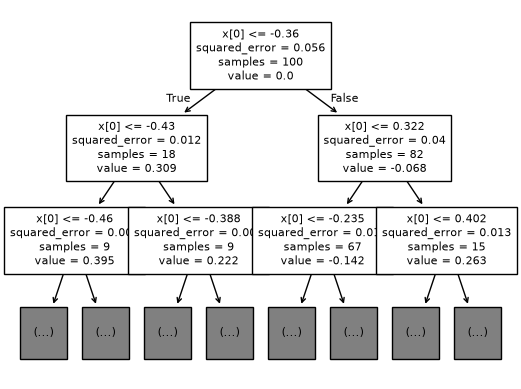

In [139]:
from sklearn.tree import plot_tree
plot_tree(t1,max_depth=2,fontsize=8)
plt.show()

In [140]:
X_test = np.linspace(-5,5,500)

In [141]:
y_pred = 0.265458 + t1.predict(X_test.reshape(500,1))

(-0.5, 0.5)

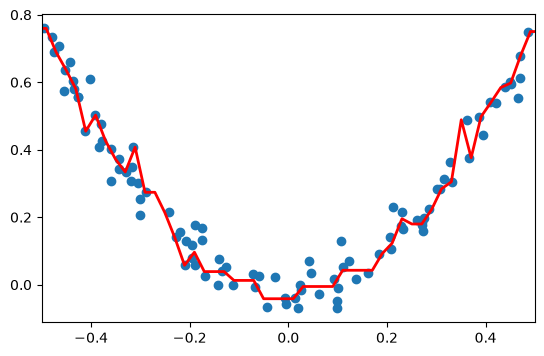

In [142]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.scatter(df['X'],df['y'])
plt.plot(X_test,y_pred,color='red',linewidth=2)
plt.xlim(-0.5,0.5)

In [143]:
df['pred2'] = 0.265458 + t1.predict(df['X'].values.reshape(100,1))

In [144]:
df

,X,y,pred1,res1,pred2
0,-0.125460,0.051573,0.265458,-0.213885,0.038881
1,0.450714,0.594480,0.265458,0.329021,0.597626
2,0.231994,0.166052,0.265458,-0.099407,0.179941
3,0.098658,-0.070178,0.265458,-0.335636,-0.005301
4,-0.343981,0.343986,0.265458,0.078528,0.334017
...,...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133,-0.041576
96,0.022733,-0.002305,0.265458,-0.267763,-0.005301
97,-0.072459,0.032809,0.265458,-0.232650,0.012734
98,-0.474581,0.689516,0.265458,0.424057,0.689515


In [145]:
df['res2'] = df['y'] - df['pred2']

In [146]:
df

,X,y,pred1,res1,pred2,res2
0,-0.125460,0.051573,0.265458,-0.213885,0.038881,1.269182e-02
1,0.450714,0.594480,0.265458,0.329021,0.597626,-3.145898e-03
2,0.231994,0.166052,0.265458,-0.099407,0.179941,-1.388927e-02
3,0.098658,-0.070178,0.265458,-0.335636,-0.005301,-6.487648e-02
4,-0.343981,0.343986,0.265458,0.078528,0.334017,9.969285e-03
...,...,...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133,-0.041576,9.009411e-04
96,0.022733,-0.002305,0.265458,-0.267763,-0.005301,2.996734e-03
97,-0.072459,0.032809,0.265458,-0.232650,0.012734,2.007499e-02
98,-0.474581,0.689516,0.265458,0.424057,0.689515,3.966968e-07


In [147]:
t2 = DecisionTreeRegressor(max_depth=8)

In [148]:
t2.fit(df['X'].values.reshape(100,1),df['res2'].values)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

In [149]:
X_test.shape

(500,)

In [150]:
y_pred = 0.265458 + t1.predict(X_test.reshape(500,1)) + t2.predict(X_test.reshape(500,1))

(-0.5, 0.5)

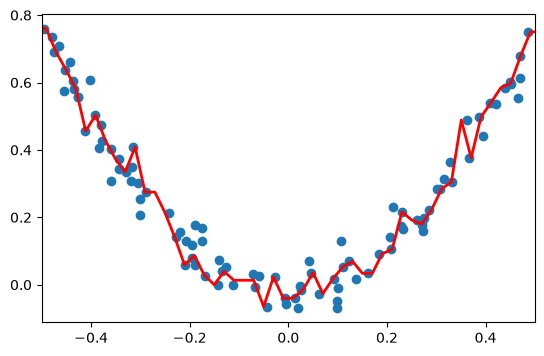

In [151]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.scatter(df['X'],df['y'])
plt.plot(X_test,y_pred,color='red',linewidth=2)
plt.xlim(-0.5,0.5)

In [152]:
def gradient_boost_fit(X,y,n_trees,lr=0.1):
    base_pred = y.mean()
    res = y - base_pred
    trees = []
    for i in range(n_trees):
        tree = DecisionTreeRegressor(max_depth=4)
        tree.fit(X,res)
        trees.append(tree)
        res = res - lr*tree.predict(X)
    return base_pred,trees

def gradient_boost_predict(X,trees, base_pred,lr=0.1):
    y_pred = np.full(X.shape[0], base_pred)
    for tree in trees:
        y_pred = y_pred + lr * tree.predict(X)
    return y_pred

In [153]:
X_test = np.linspace(-0.5, 0.5, 500).reshape(-1, 1)

In [154]:
base_pred, trees = gradient_boost_fit(X=X,y=y,n_trees=5,lr=0.2)

In [155]:
pred = gradient_boost_predict(X_test,trees,base_pred=0.26545839669679816,lr=0.2)

In [156]:
from sklearn.datasets import load_diabetes
X,y = load_diabetes(return_X_y=True)

In [157]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [158]:
base_pred, trees = gradient_boost_fit(X=X_train,y=y_train,n_trees=5,lr=0.2)

In [159]:
y_pred = gradient_boost_predict(X=X_test,trees=trees,base_pred=base_pred,lr=0.2)

In [160]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test,y_pred)

3117.484274953025